In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
%matplotlib inline

sys.path.append('../../')
from envs import SwitchCorridor
from models.policy_gradient import reinforce

In [2]:
class Agent(nn.Module):
    
    def __init__(self, input_size, output_size):
        super().__init__()
        self.l1 = nn.Linear(input_size, output_size)
        nn.init.uniform_(self.l1.weight, 0, 0.001)
        
    def forward(self, x):
        x0 = torch.Tensor(x[0])
        x1 = torch.Tensor(x[1])
        x0 = self.l1(x0)
        x1 = self.l1(x1)
        x  = torch.cat([x0, x1])
        return F.softmax(x).view(1,-1)

In [3]:
eps = np.finfo(np.float32).eps.item()
env = SwitchCorridor()
agent = Agent(env.observation_space_n, 1)

In [5]:
gamma    = .9
episodes = 1000

rewards = list()
for _ in range(episodes): 
    total_reward = reinforce(agent, env, gamma)
    rewards.append(total_reward)

In [6]:
policy = agent([[1,0],[0,1]]).detach()
policy

tensor([[0.4556, 0.5444]])

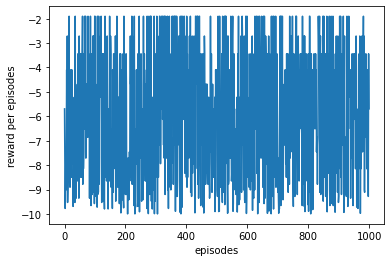

In [7]:
plt.plot(rewards)
plt.xlabel('episodes')
plt.ylabel('reward per episodes')
plt.show()